# Bank Marketing Business Analytics Case Study

## Business Problem
Problem Statement

The bank wants to increase the success rate of its marketing campaigns while reducing unnecessary marketing costs. The objective of this analysis is to identify the customer characteristics and campaign factors that influence whether a customer subscribes to a term deposit.

Business Questions

1. Which customers are more likely to subscribe?

2. Which marketing methods perform best?

3. Does age affect subscription?

4. Does education matter?

5. Does previous campaign success matter?

6. Which occupations respond positively?

7. Which months generate better responses?

## Importing Libraries 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('../Data/bank.csv')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## Dataset Overview

In [3]:
print(df.shape)
df.info()
df.describe(include='all').T

(11162, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,11162.0,NaN,NaN,NaN,41.231948,11.913369,18.0,32.0,39.0,49.0,95.0
job,11162,12,management,2566,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,11162,3,married,6351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,11162,4,secondary,5476,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,11162,2,no,10994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,11162.0,NaN,NaN,NaN,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.0,81204.0
housing,11162,2,no,5881,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,11162,2,no,9702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,11162,3,cellular,8042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,11162.0,NaN,NaN,NaN,15.658036,8.42074,1.0,8.0,15.0,22.0,31.0


## Data Quality Checks

### Missing Values 

In [4]:
print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


In [5]:

print('Duplicates:',df.duplicated().sum())

Duplicates: 0


# Exploratory Data Analysis

### Target Distribution


In [15]:
# Calculate the percentage of customers who subscribed within each category
def subscription_rate(data, column):
    rate = pd.crosstab(
        data[column],
        data["deposit"],
        normalize="index"
    )["yes"] * 100
    
    return rate.sort_values(ascending=False)

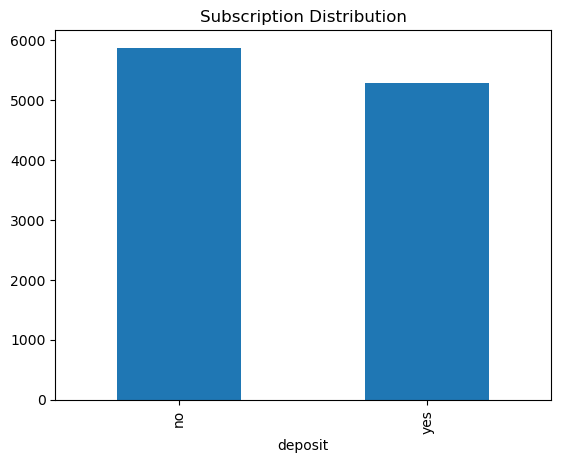

In [16]:
df['deposit'].value_counts().plot(kind='bar');
plt.title('Subscription Distribution');
plt.savefig('../Visualizations/Target_Dist.png')
plt.show()


### Overall Subscription Rate 

In [18]:
# Calculation
Overall_subscription_rate = df["deposit"].value_counts(normalize=True) * 100

print(Overall_subscription_rate)

deposit
no     52.616019
yes    47.383981
Name: proportion, dtype: float64


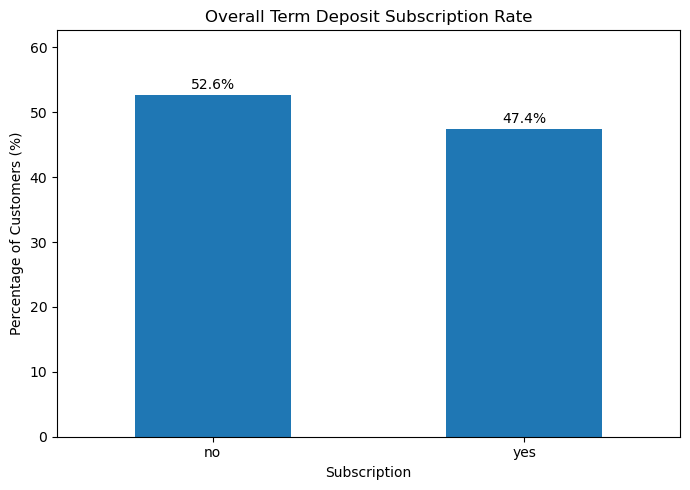

In [47]:
# Plot 
plt.figure(figsize=(7, 5))

ax = Overall_subscription_rate.plot(
    kind="bar"
)

plt.title("Overall Term Deposit Subscription Rate")
plt.xlabel("Subscription")
plt.ylabel("Percentage of Customers (%)")
plt.xticks(rotation=0)

# Add percentage labels above the bars
for i, value in enumerate(Overall_subscription_rate):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.ylim(0, Overall_subscription_rate.max() + 10)
plt.tight_layout()
plt.savefig('../Visualizations/Overall_sub_rate.png')
plt.show()


## Age Distribution


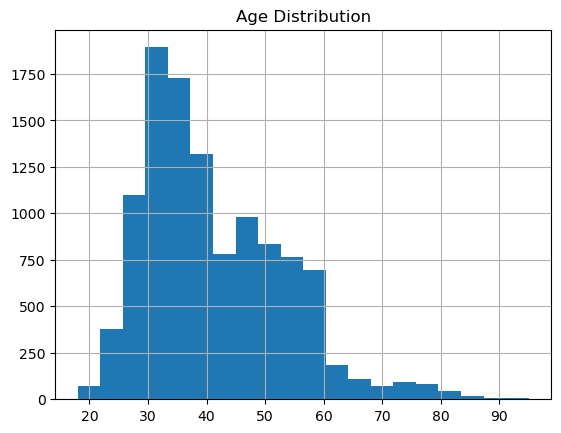

In [21]:
df['age'].hist(bins=20);
plt.title('Age Distribution');
plt.savefig('../Visualizations/Age_Dist.png')
plt.show()

## Subscription By Job 


### Distribution 

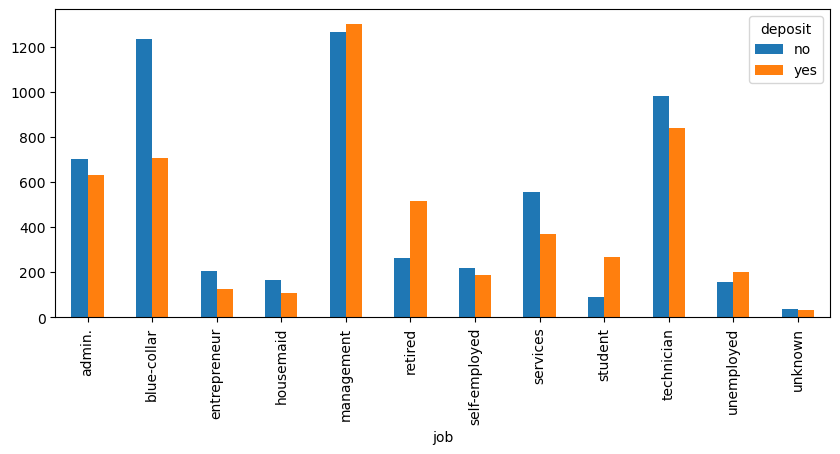

In [22]:
pd.crosstab(df['job'],df['deposit']).plot(kind='bar',figsize=(10,4));
plt.savefig('../Visualizations/sub_by_job.png')
plt.show()


### Subscription rate by job 

In [23]:
# Calculate subscription rate for each job category
job_rate = subscription_rate(df, "job")

print(job_rate)

job
student          74.722222
retired          66.323907
unemployed       56.582633
management       50.701481
unknown          48.571429
admin.           47.301349
self-employed    46.172840
technician       46.077894
services         39.978332
housemaid        39.781022
entrepreneur     37.500000
blue-collar      36.419753
Name: yes, dtype: float64


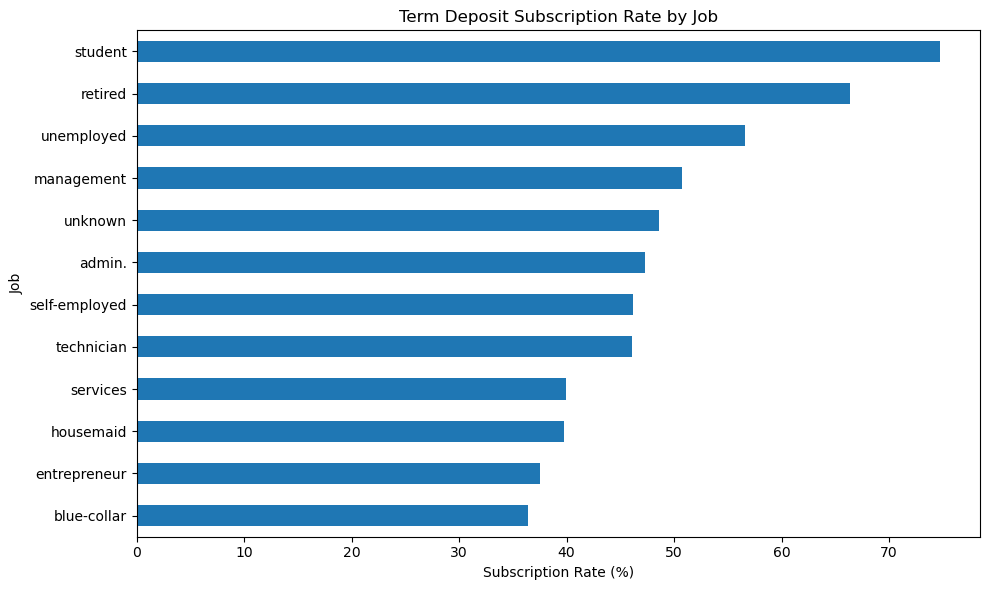

In [24]:
plt.figure(figsize=(10, 6))

job_rate.sort_values().plot(
    kind="barh"
)

plt.title("Term Deposit Subscription Rate by Job")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")

plt.tight_layout()
plt.savefig('../Visualizations/sub_rate_by_job.png')
plt.show()


## Subscription By Education 


### Distribution

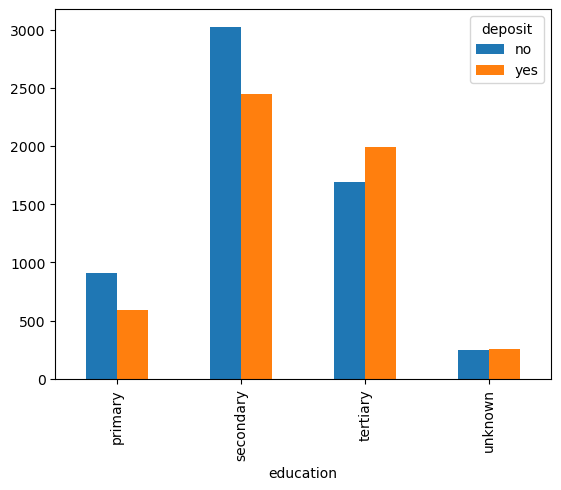

In [25]:
pd.crosstab(df['education'],df['deposit']).plot(kind='bar');
plt.savefig('../Visualizations/sub_by_edu.png')
plt.show()


### Subscription Rate by Education

In [26]:
education_rate = subscription_rate(df, "education")

print(education_rate)

education
tertiary     54.106804
unknown      50.704225
secondary    44.740687
primary      39.400000
Name: yes, dtype: float64


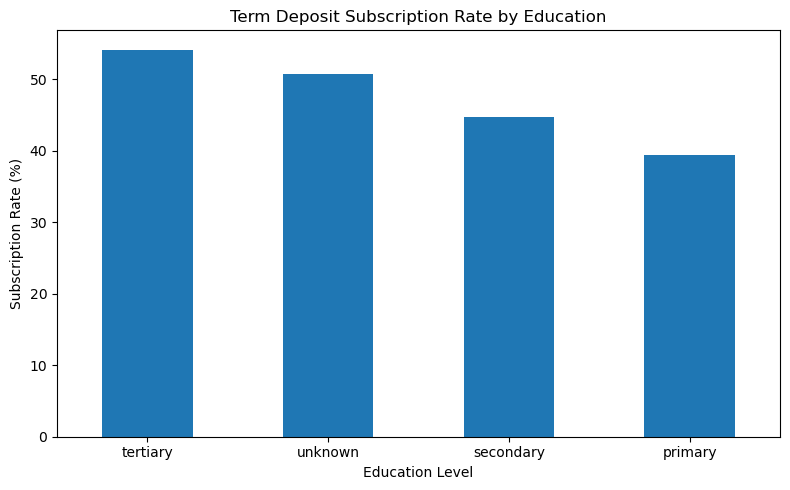

In [27]:
plt.figure(figsize=(8, 5))

education_rate.plot(
    kind="bar"
)

plt.title("Term Deposit Subscription Rate by Education")
plt.xlabel("Education Level")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('../Visualizations/sub_rate_by_edu.png')
plt.show()


## Subscription By Marital Status

### Distribution

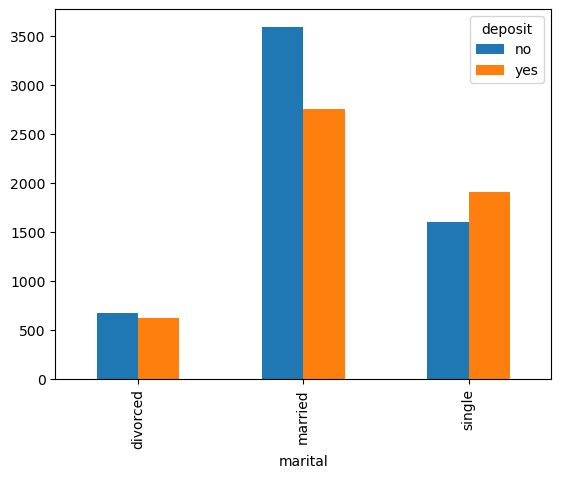

In [28]:
pd.crosstab(df['marital'],df['deposit']).plot(kind='bar');
plt.savefig('../Visualizations/sub_by_ms.png')
plt.show()


### Subsciption Rate by Marital Status 

In [29]:
marital_rate = subscription_rate(df, "marital")

print(marital_rate)

marital
single      54.349062
divorced    48.105182
married     43.378995
Name: yes, dtype: float64


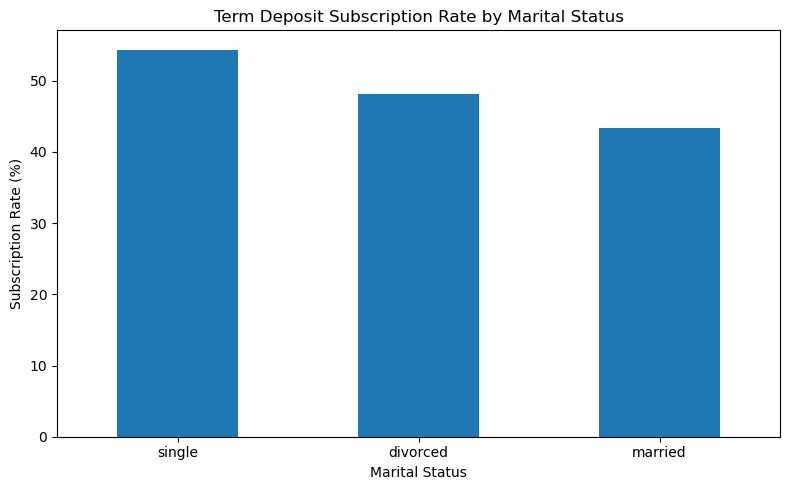

In [30]:
plt.figure(figsize=(8, 5))

marital_rate.plot(
    kind="bar"
)

plt.title("Term Deposit Subscription Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('../Visualizations/sub_rate_by_ms.png')
plt.show()


## Subscription By Contact Method


### Distribution

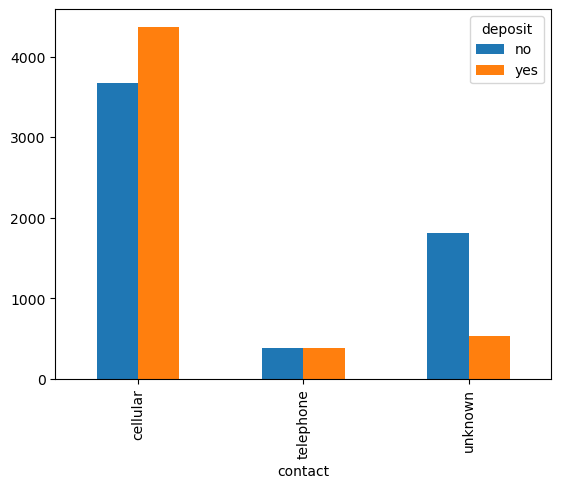

In [31]:
pd.crosstab(df['contact'],df['deposit']).plot(kind='bar');
plt.savefig('../Visualizations/sub_by_cm.png')
plt.show()


### Subscription Rate by Contact Method 

In [32]:
contact_rate = subscription_rate(df, "contact")

print(contact_rate)

contact
cellular     54.327282
telephone    50.387597
unknown      22.591645
Name: yes, dtype: float64


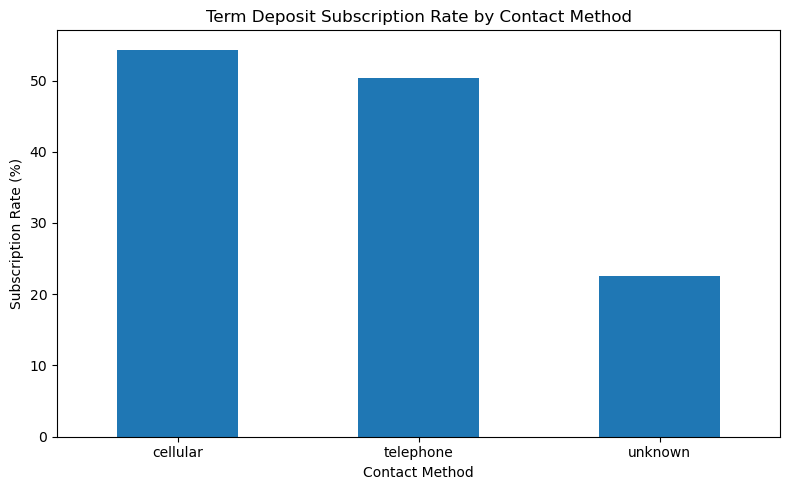

In [33]:
plt.figure(figsize=(8, 5))

contact_rate.plot(
    kind="bar"
)

plt.title("Term Deposit Subscription Rate by Contact Method")
plt.xlabel("Contact Method")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('../Visualizations/sub_rate_by_cm.png')
plt.show()


## Month of Contact

### Distribution

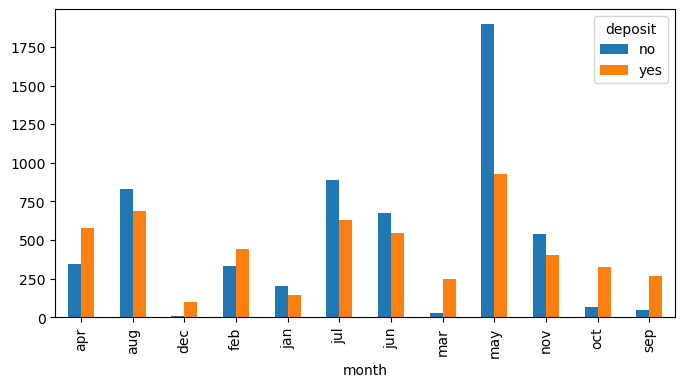

In [34]:
pd.crosstab(df['month'],df['deposit']).plot(kind='bar',figsize=(8,4));
plt.savefig('../Visualizations/Month_of_Contact.png')
plt.show()


### Subscription Rate by Month

In [35]:
# Define chronological month order
month_order = [
    "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec"
]

# Calculate monthly subscription rates
month_rate = subscription_rate(df, "month")

# Reorder the months chronologically
month_rate = month_rate.reindex(month_order)

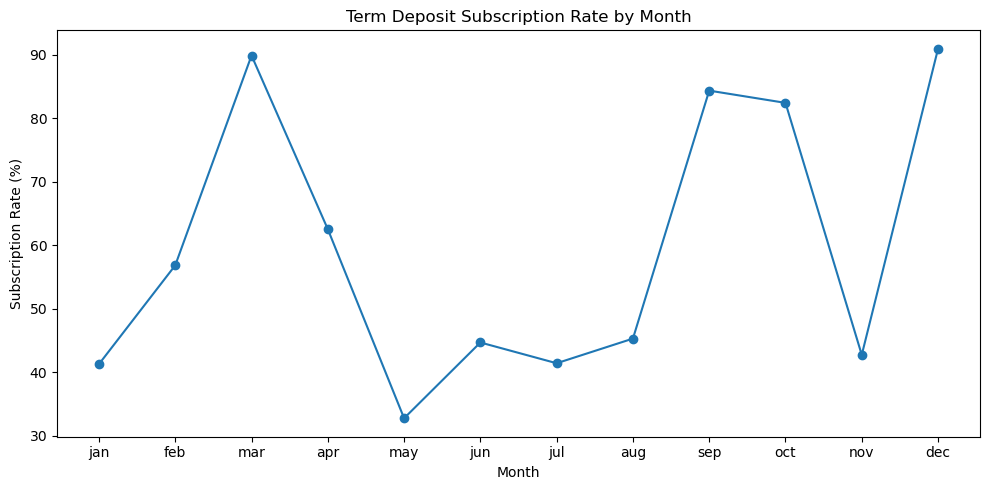

In [36]:
plt.figure(figsize=(10, 5))

plt.plot(
    month_rate.index,
    month_rate.values,
    marker="o"
)

plt.title("Term Deposit Subscription Rate by Month")
plt.xlabel("Month")
plt.ylabel("Subscription Rate (%)")

plt.tight_layout()
plt.savefig('../Visualizations/sub_rate_by_month.png')
plt.show()


## Previous Campaign Outcome

### Distribution 

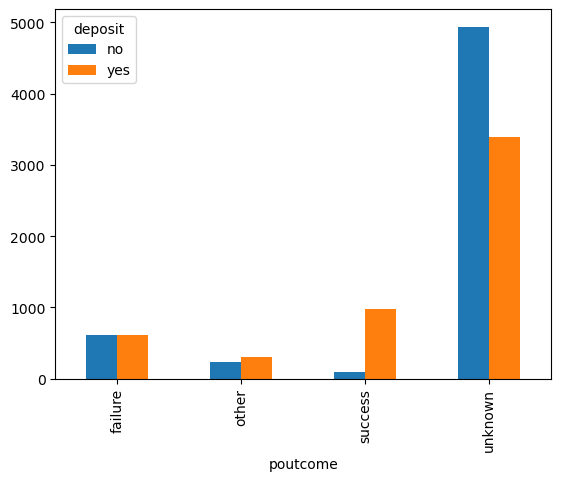

In [37]:
pd.crosstab(df['poutcome'],df['deposit']).plot(kind='bar');
plt.savefig('../Visualizations/PCC.png')
plt.show()


### Subscription Rate by Previous Campaign Outcome 

In [38]:
poutcome_rate = subscription_rate(df, "poutcome")

print(poutcome_rate)

poutcome
success    91.316527
other      57.169460
failure    50.325733
unknown    40.667788
Name: yes, dtype: float64


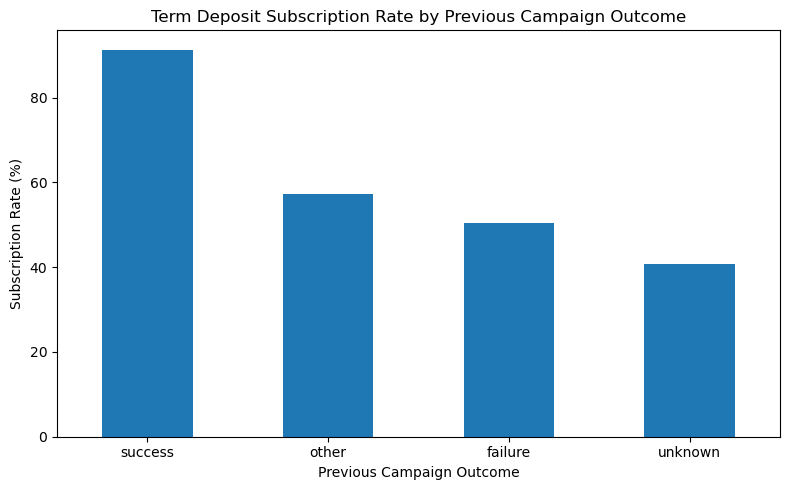

In [39]:
plt.figure(figsize=(8, 5))

poutcome_rate.plot(
    kind="bar"
)

plt.title("Term Deposit Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('../Visualizations/sub_rate_by_pcc.png')
plt.show()


## Boxplot - Subscription By Age 


### Distribution

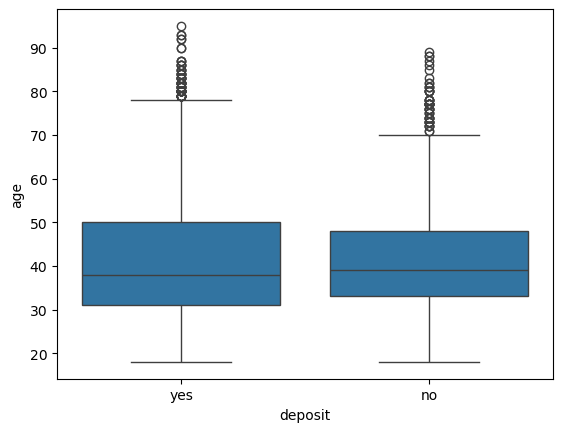

In [40]:
sns.boxplot(x='deposit',y='age',data=df);
plt.savefig('../Visualizations/sub_by_age.png')
plt.show()


### Subscription Rate By Age Group

In [41]:
# Create meaningful customer age groups
df["age_group"] = pd.cut(
    df["age"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=[
        "18–25",
        "26–35",
        "36–45",
        "46–55",
        "56–65",
        "66+"
    ]
)

In [42]:
age_rate = subscription_rate(df, "age_group")

print(age_rate)

age_group
66+      80.402010
18–25    71.111111
56–65    53.959484
26–35    47.666412
46–55    41.554211
36–45    41.196960
Name: yes, dtype: float64


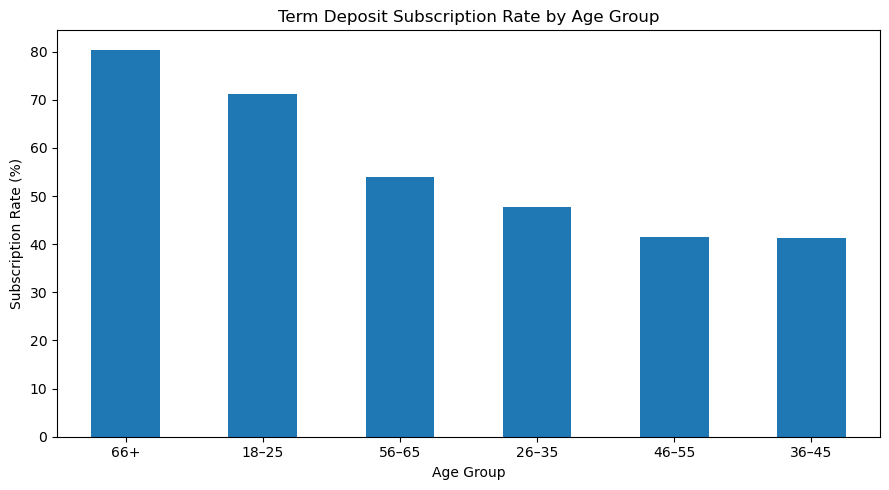

In [43]:
plt.figure(figsize=(9, 5))

age_rate.plot(
    kind="bar"
)

plt.title("Term Deposit Subscription Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('../Visualizations/sub_rate_by_agegroup.png')
plt.show()


## Correlation Heatmap


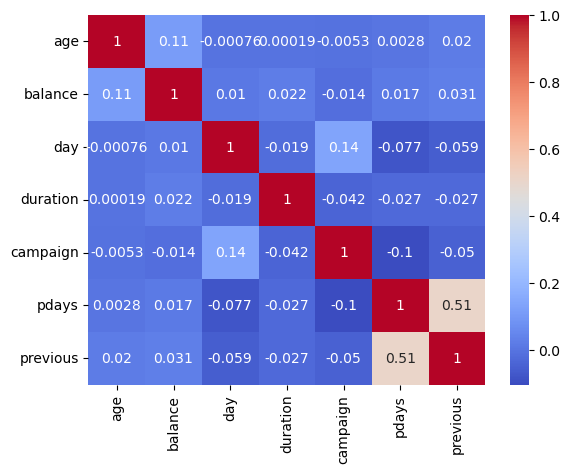

In [44]:
num=df.select_dtypes('number');
sns.heatmap(num.corr(),annot=True,cmap='coolwarm');
plt.savefig('../Visualizations/CH.png')
plt.show()
